### Análisis de datos II
## Clustering basado en densidad
### DBSCAN. HDBSCAN.

Ejemplos con dataset sintético.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def plot_clusters(X, labels, core_sample_indices=None, ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    unique_labels = set(labels)

    # Cantidad de clusters y ruido
    n_clusters = len(unique_labels - {-1})
    n_noise = np.sum(labels == -1)

    print(f"Número de clusters: {n_clusters}")
    print(f"Ruido: {n_noise}")

    # Colores
    colors = [
        plt.cm.Spectral(each)
        for each in np.linspace(0, 1, len(unique_labels))
    ]

    # -------------------------
    # DBSCAN: core / no-core
    # -------------------------
    if core_sample_indices is not None:

        core_samples_mask = np.zeros_like(labels, dtype=bool)
        core_samples_mask[core_sample_indices] = True

        for k, col in zip(unique_labels, colors):

            if k == -1:
                col = [0, 0, 0, 1]

            class_member_mask = labels == k

            # Core
            xy = X[class_member_mask & core_samples_mask]
            ax.plot(
                xy[:, 0], xy[:, 1],
                "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=10
            )

            # No-core
            xy = X[class_member_mask & ~core_samples_mask]
            ax.plot(
                xy[:, 0], xy[:, 1],
                "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=5
            )

    # -------------------------
    # HDBSCAN
    # -------------------------
    else:

        for k, col in zip(unique_labels, colors):

            class_member_mask = labels == k

            if k == -1:
                col = [0, 0, 0, 1]
                size = 5
            else:
                size = 10

            xy = X[class_member_mask]

            ax.plot(
                xy[:, 0], xy[:, 1],
                "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=size
            )

    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_title(f"{n_clusters} clusters")

    plt.show()

---
### DATASET SINTÉTICO

In [3]:
from sklearn.datasets import make_blobs

In [4]:
X, _ = make_blobs(
    n_samples=750,
    centers=[[1, 1], [-1, -1], [1.2, -1.2]],
    cluster_std=[0.48, 0.1, 0.75],
    random_state=0
)
X.shape

(750, 2)

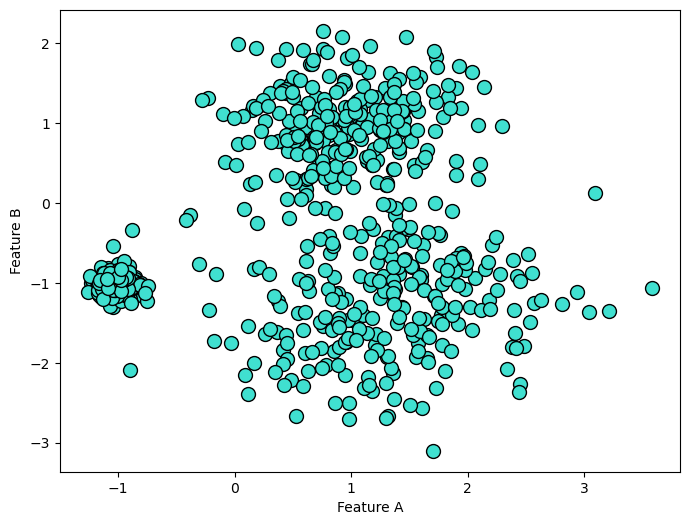

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(X[:, 0], X[:, 1],
                "o",
                markerfacecolor='turquoise',
                markeredgecolor="k",
                markersize=10)
plt.xlabel("Feature A")
plt.ylabel("Feature B")
plt.show()

---
### DBSCAN

In [6]:
from sklearn.cluster import DBSCAN

Con DBSCAN no especificamos el número de clusters. Experimentamos con los hiperparámetros.

Empezamos con epsilon moderado y el mínimo número de samples 5 (es el valor por defecto).

In [7]:
db = DBSCAN(eps=0.5, min_samples=5).fit(X)
db

,eps,0.5
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [8]:
n_clusters = len(set(db.labels_) - {-1})
n_noise = np.sum(db.labels_ == -1)

print(f"Número de clusters: {n_clusters}")
print(f"Ruido: {n_noise}")

Número de clusters: 2
Ruido: 3


Número de clusters: 2
Ruido: 3


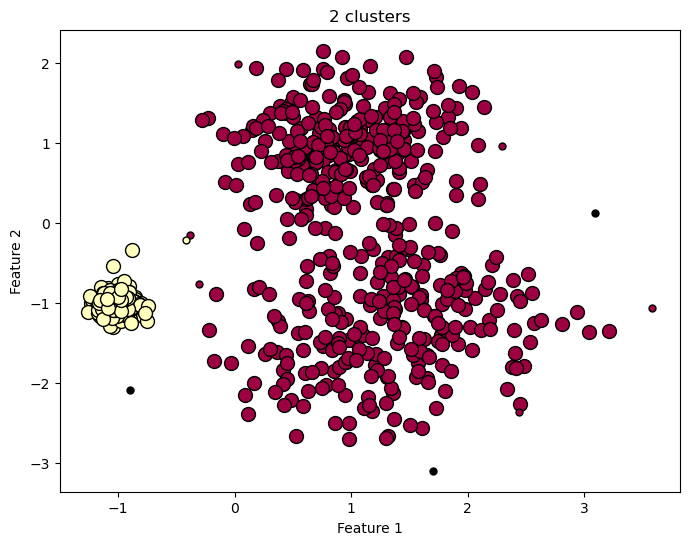

In [9]:
plot_clusters(X, db.labels_, db.core_sample_indices_)

Aumentamos `min_samples` para que sea más estricto con la densidad, y que marque como ruido los puntos dispersos.

Número de clusters: 2
Ruido: 11


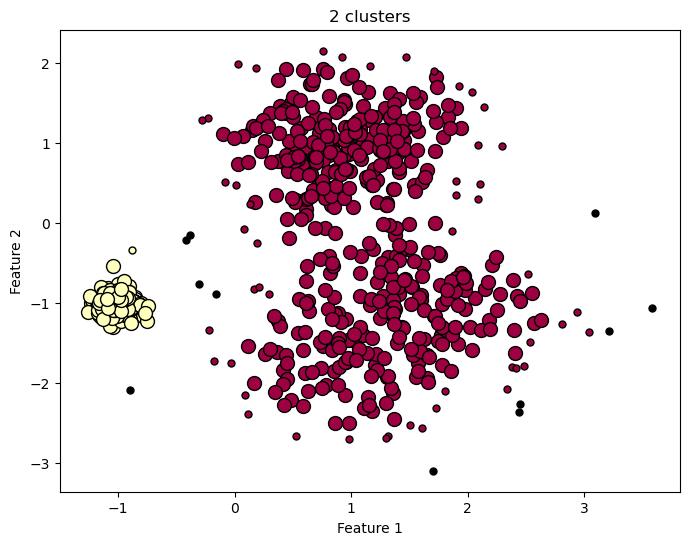

In [10]:
db = DBSCAN(eps=0.5, min_samples=15).fit(X)
plot_clusters(X, db.labels_, db.core_sample_indices_)

Logramos el objetivo. A las observaciones que no están tan cerca de los centros, las marca como ruido.

Vamos a achicar epsilon, es decir, reducir el radio de vecindad de los core points. Buscamos romper las conexiones largas o espacios vacíos entre grupos.

Número de clusters: 7
Ruido: 82


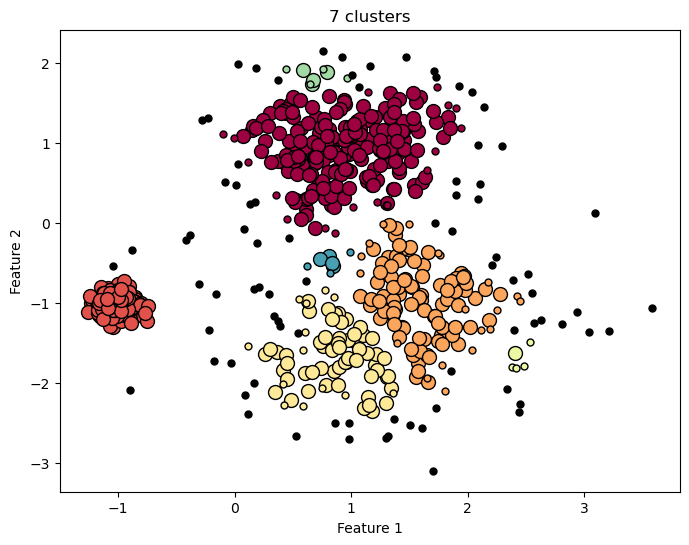

In [11]:
db = DBSCAN(eps=0.2, min_samples=5).fit(X)
plot_clusters(X, db.labels_, db.core_sample_indices_)

Al pedir más vecinos para formar un core point, las zonas cque tienen puntos un poco más dispersos causan que los clusters se fragmentan. Además, se genera más ruido.

Ajustamos nuevamente epsilon.

Número de clusters: 3
Ruido: 118


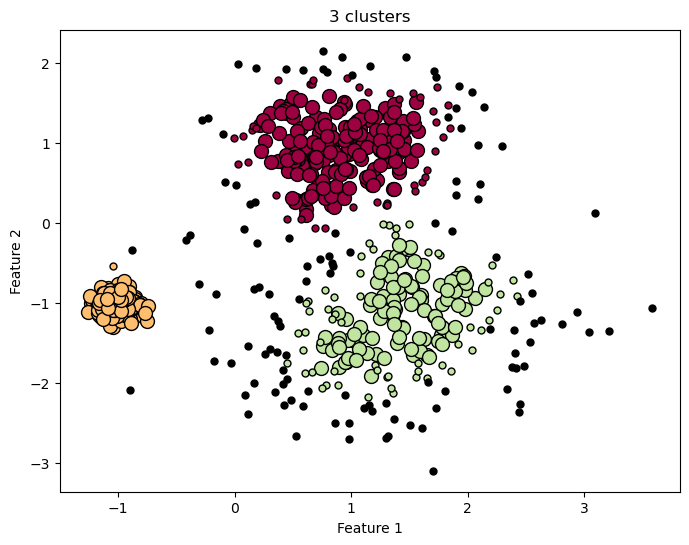

In [12]:
db = DBSCAN(eps=0.3, min_samples=15).fit(X)
plot_clusters(X, db.labels_, db.core_sample_indices_)

Pudimos generar 3 clusters, pero dio trabajo configurar los hiperparámetros para lidiar con la densidad de los clusters grandes.

---
### HDBSCAN

In [13]:
from sklearn.cluster import HDBSCAN

Vamos a probar con hiperparámetros por defecto.

Número de clusters: 2
Ruido: 8


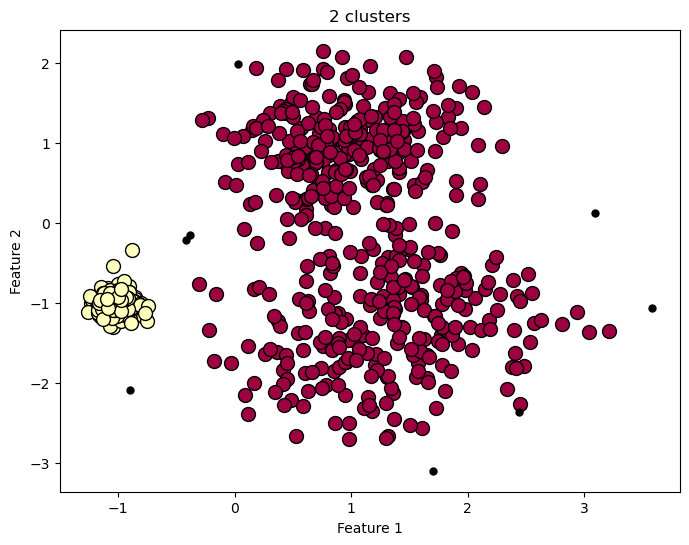

In [14]:
hdb = HDBSCAN().fit(X)
plot_clusters(X, hdb.labels_)

El algoritmo considera que el mejor agrupamiento está conformado por dos clusters.

Probemos otra configuración.

Número de clusters: 38
Ruido: 148


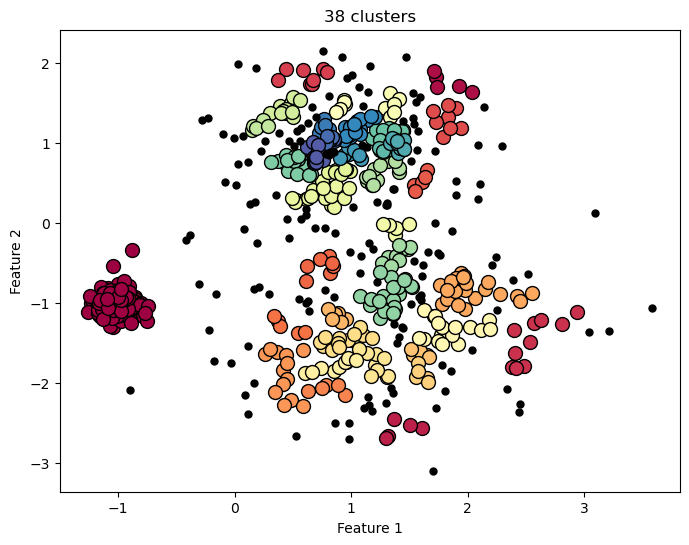

In [15]:
hdb = HDBSCAN(min_samples=2).fit(X)
plot_clusters(X, hdb.labels_)

Se generaron demasiados clusters chiquitos.

Una opción, si quisieramos juntar los clusters que están demasiado juntos, es poner un umbral de distancia (`cluster_selection_epsilon`). Los clusters que estén a una distancia menor, se combinan.

Número de clusters: 4
Ruido: 41


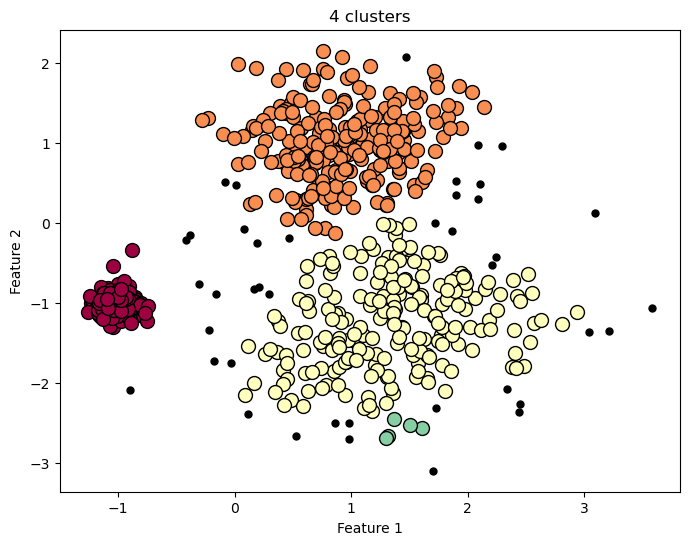

In [16]:
hdb = HDBSCAN(min_samples=2, cluster_selection_epsilon= 0.21).fit(X)

plot_clusters(X, hdb.labels_)

La agrupación, de 4 clusters, es muy similar a la que esperábamos (ya que los datos sintéticos fueron creados a partir de 3 distribuciones).

Si de entrada ya sabemos que queremos exactamente 3 clusters, HDBSCAN no sería la opción indicada.